In [1]:
import scanpy as sc
import pandas as pd 
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from matplotlib.colors import LinearSegmentedColormap


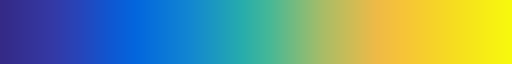

In [2]:
RNA_colors = ["#352A86", "#343296", "#343AA7", "#2646BB", "#1156D0", "#0366DE", "#0A76D8", "#1286D2", "#1C99C0", "#27ADAC", "#46B897", "#78BB7E", "#A9BD67", "#CCBC57", "#EFBA47", "#F7C438", "#F6D12B", "#F6DF1F", "#F7EC16", "#F8FA0D"]
RNA_cmap = LinearSegmentedColormap.from_list("my_cmap", RNA_colors, N=256)
RNA_cmap

In [3]:
# annotation
anno = pd.read_csv("/cluster2/huanglab/jiamao/Project/HumanSpinalCord/Work/P3/ATAC/Snapatac2/HSC/atac-meta.csv", index_col=0)
anno

,sample2,barcode2,cell_type_snRNA
AAACAGCCAGCAAGAT-1-0,GW6,AAACAGCCAGCAAGAT-1,APC_ventral
AAACAGCCATAAAGCA-1-0,GW6,AAACAGCCATAAAGCA-1,InN_ventral_2
AAACAGCCATCGTTCT-1-0,GW6,AAACAGCCATCGTTCT-1,NPC
AAACAGCCATTAGGTT-1-0,GW6,AAACAGCCATTAGGTT-1,Schwann
AAACCAACAAAGCTCC-1-0,GW6,AAACCAACAAAGCTCC-1,Microglia
...,...,...,...
TTTGTTGGTCACAAAT-1-7,GW20,TTTGTTGGTCACAAAT-1,OPC
TTTGTTGGTTACTAGG-1-7,GW20,TTTGTTGGTTACTAGG-1,APC_dorsal
TTTGTTGGTTAGGACC-1-7,GW20,TTTGTTGGTTAGGACC-1,NPC_proliferative
TTTGTTGGTTGCACAA-1-7,GW20,TTTGTTGGTTGCACAA-1,APC_ventral


In [5]:
adata_raw = sc.read_h5ad('/cluster2/huanglab/jiamao/Project/HumanSpinalCord/Work/P2/data/scMulti-omics/1.hscAdata_raw.h5ad')
adata_ref = adata_raw[adata_raw.obs.index.isin(anno.index)]
adata_ref.obs = adata_ref.obs.join(anno)
adata_ref.obs = adata_ref.obs[['sample2', 'barcode2', 'cell_type_snRNA']]
# target_celltypes = [
#     "NPC_proliferative", "NPC", "dIPC", "vIPC", "dorsal_glia", "ventral_glia", "ExN_naive", "ExN_immature_1", "ExN_immature_2", "ExN_immature_3", "ExN_mature_1", "ExN_mature_2", "ExN_mature_3",
#     "InN_naive", "InN_immature_1", "InN_immature_2", "InN_mature_1", "InN_mature_2", "InN_ventral_like", "ventral_unknow", "v0_1", "v2a_b", "MN1", "MN2", "OPC", "Ependymal", "FP", "RP", "Microglia", "VLMC"#, "EC"
# ]
# # 筛选adata对象中指定细胞类型的细胞
# adata_ref = adata_ref[adata_ref.obs['celltype'].isin(target_celltypes)].copy()
adata_ref

AnnData object with n_obs × n_vars = 69282 × 36601
    obs: 'sample2', 'barcode2', 'cell_type_snRNA'
    var: 'gene_ids', 'feature_types'

In [6]:
adata_ref.raw = adata_ref
# sc.pp.normalize_total(adata_ref, target_sum=1e4)
# sc.pp.log1p(adata_ref)
adata_ref.obs = adata_ref.obs.rename(lambda x: f"{x}___cisTopic", axis=0)


In [7]:
adata_ref.obs

,sample2,barcode2,cell_type_snRNA
AAACAGCCAGCAAGAT-1-0___cisTopic,GW6,AAACAGCCAGCAAGAT-1,APC_ventral
AAACAGCCATAAAGCA-1-0___cisTopic,GW6,AAACAGCCATAAAGCA-1,InN_ventral_2
AAACAGCCATCGTTCT-1-0___cisTopic,GW6,AAACAGCCATCGTTCT-1,NPC
AAACAGCCATTAGGTT-1-0___cisTopic,GW6,AAACAGCCATTAGGTT-1,Schwann
AAACCAACAAAGCTCC-1-0___cisTopic,GW6,AAACCAACAAAGCTCC-1,Microglia
...,...,...,...
TTTGTTGGTCACAAAT-1-7___cisTopic,GW20,TTTGTTGGTCACAAAT-1,OPC
TTTGTTGGTTACTAGG-1-7___cisTopic,GW20,TTTGTTGGTTACTAGG-1,APC_dorsal
TTTGTTGGTTAGGACC-1-7___cisTopic,GW20,TTTGTTGGTTAGGACC-1,NPC_proliferative
TTTGTTGGTTGCACAA-1-7___cisTopic,GW20,TTTGTTGGTTGCACAA-1,APC_ventral


In [8]:
adata_ref.write('/cluster2/huanglab/jiamao/Project/HumanSpinalCord/Work/P3/ATAC/Scenicplus/HSC/data/hsc.h5ad')

In [9]:
adata_ref.raw.to_adata().obs

,sample2,barcode2,cell_type_snRNA
AAACAGCCAGCAAGAT-1-0___cisTopic,GW6,AAACAGCCAGCAAGAT-1,APC_ventral
AAACAGCCATAAAGCA-1-0___cisTopic,GW6,AAACAGCCATAAAGCA-1,InN_ventral_2
AAACAGCCATCGTTCT-1-0___cisTopic,GW6,AAACAGCCATCGTTCT-1,NPC
AAACAGCCATTAGGTT-1-0___cisTopic,GW6,AAACAGCCATTAGGTT-1,Schwann
AAACCAACAAAGCTCC-1-0___cisTopic,GW6,AAACCAACAAAGCTCC-1,Microglia
...,...,...,...
TTTGTTGGTCACAAAT-1-7___cisTopic,GW20,TTTGTTGGTCACAAAT-1,OPC
TTTGTTGGTTACTAGG-1-7___cisTopic,GW20,TTTGTTGGTTACTAGG-1,APC_dorsal
TTTGTTGGTTAGGACC-1-7___cisTopic,GW20,TTTGTTGGTTAGGACC-1,NPC_proliferative
TTTGTTGGTTGCACAA-1-7___cisTopic,GW20,TTTGTTGGTTGCACAA-1,APC_ventral


In [3]:
adata_ref = sc.read_h5ad('/cluster2/huanglab/jiamao/Project/HumanSpinalCord/Work/P3/ATAC/Scenicplus/HSC/data/hsc.h5ad')

In [10]:
adata = adata_ref

In [11]:
# Saving count data
adata.layers["counts"] = adata.X.copy()
# Normalizing to median total counts
sc.pp.normalize_total(adata)
# Logarithmize the data
sc.pp.log1p(adata)
sc.pp.highly_variable_genes(adata, n_top_genes=10000, batch_key="sample2")
sc.tl.pca(adata)
sc.pp.neighbors(adata, n_neighbors=30, n_pcs=30)
sc.external.pp.bbknn(adata, 
                     batch_key="sample2",
                     n_pcs = 50,
                     use_annoy= False,
                     pynndescent_n_neighbors = 40
                    )  # running bbknn 1.3.6

sc.tl.umap(adata, 
           min_dist = 0.5, 
           spread = 0.8)

/cluster2/huanglab/jiamao/conda/envs/R-4.3.0/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [12]:
# Obtain cluster-specific differentially expressed genes
sc.tl.rank_genes_groups(adata, groupby="cell_type_snRNA", method="wilcoxon",key_added="rank_genes_celltype")

/cluster2/huanglab/jiamao/conda/envs/R-4.3.0/lib/python3.12/site-packages/scanpy/tools/_rank_genes_groups.py:429: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  self.stats[group_name, "names"] = self.var_names[global_indices]
/cluster2/huanglab/jiamao/conda/envs/R-4.3.0/lib/python3.12/site-packages/scanpy/tools/_rank_genes_groups.py:431: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  self.stats[group_name, "scores"] = scores[global_indices]
/cluster2/huanglab/jiamao/conda/envs/R-4.3.0/lib/python3.12/site-packages/scanpy/tools/_ran

In [13]:
adata

AnnData object with n_obs × n_vars = 69282 × 36601
    obs: 'sample2', 'barcode2', 'cell_type_snRNA'
    var: 'gene_ids', 'feature_types', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'highly_variable_nbatches', 'highly_variable_intersection'
    uns: 'log1p', 'hvg', 'pca', 'neighbors', 'umap', 'rank_genes_celltype'
    obsm: 'X_pca', 'X_umap'
    varm: 'PCs'
    layers: 'counts'
    obsp: 'distances', 'connectivities'

In [15]:
marker_cell_type = sc.get.rank_genes_groups_df(adata, group=None, key = 'rank_genes_celltype', log2fc_min =0.25, pval_cutoff=0.01)
marker_cell_type

,group,names,scores,logfoldchanges,pvals,pvals_adj
0,APC_cycling,NFIA,64.245064,2.660190,0.000000,0.000000
1,APC_cycling,LRIG1,61.661537,2.860031,0.000000,0.000000
2,APC_cycling,PARD3B,61.005936,2.561016,0.000000,0.000000
3,APC_cycling,MIR99AHG,60.458000,1.688614,0.000000,0.000000
4,APC_cycling,C1orf61,59.688053,2.267431,0.000000,0.000000
...,...,...,...,...,...,...
59837,VLMC,NFYC,3.362330,0.397570,0.000773,0.009645
59838,VLMC,SMTN,3.361709,1.934044,0.000775,0.009663
59839,VLMC,AC011586.2,3.361372,2.633770,0.000776,0.009672
59840,VLMC,RAB5A,3.361109,0.393485,0.000776,0.009678


In [16]:
celltype_order = ["NPC_proliferative", "NPC", "IPC", 
    "ExN_naive", "ExN_immature_1", "ExN_immature_2", "ExN_immature_3", "ExN_mature_1", "ExN_mature_2", "ExN_mature_3", "ExN_ventral",
    "InN_naive", "InN_immature_1", "InN_immature_2", "InN_mature_1", "InN_mature_2", "InN_ventral_1", "InN_ventral_2", "InN_ventral_3",
    "MN1", "MN2",
    "APC_cycling", "APC_dorsal", "APC_ventral", "AST",
    "OPC", "COP", "MFOL", "MOL",
    "RP", "MP", "FP",
    "Schwann", "EC", "VLMC", "PC", "Microglia"
]

In [17]:
marker_cell_type.to_csv('hsc_marker_celltype_de.csv', index=False)

In [18]:
marker_cell_type = pd.read_csv('hsc_marker_celltype_de.csv')

In [19]:
# 确保只保留 order 中存在的细胞类型
adata = adata[adata.obs['cell_type_snRNA'].isin(celltype_order)].copy()

# 设置 category 顺序
adata.obs['cell_type_snRNA'] = adata.obs['cell_type_snRNA'].astype('category')
adata.obs['cell_type_snRNA'] = adata.obs['cell_type_snRNA'].cat.reorder_categories(celltype_order, ordered=True)

In [20]:
# color from meijiao
my_colors = {
    #----------Pro----------
    'NPC_proliferative' : '#D27BA1',
    'NPC' : 'darkgreen',
    'IPC' : '#D10049',

    #----------EX-----------
    'ExN_naive' : '#F2684C',
    'ExN_immature_1' : '#94191D',    
    'ExN_immature_2' : '#31A352',
    'ExN_immature_3' : '#0A0288',
    'ExN_mature_1' : '#6066AF',
    'ExN_mature_2' : '#600073',
    'ExN_mature_3' : '#3182BE',
    'ExN_ventral' : '#9594CB',
    
    #----------IN-----------
    'InN_naive' : '#FFEBB2',
    'InN_immature_1' : '#FFAA7B',
    'InN_immature_2' : '#D0696A',
    'InN_mature_1' : '#841D50',
    'InN_mature_2' : '#E63D53',
    'InN_ventral_1': '#C2C9D7',
    'InN_ventral_2': '#CE0011',
    'InN_ventral_3': '#6D006A',

    #----------MN-----------
    'MN1' : '#8E0B1B',
    'MN2' : '#AEE4EA',

    #---------Astrocyte Precursors & Astrocytes---------
    'APC_cycling' : '#D15500',
    'APC_dorsal' : '#20A6E7',
    'APC_ventral' : '#0055A9',
    'AST' : '#007854',

    #---------Oligodendrocyte Lineage---------
    'OPC' : '#5C5857',
    'COP' : '#83B3D4',
    'MFOL' : '#F0A8B1',
    'MOL' : '#FFD686',

    #---------Ependymal-----------
    'RP' : '#FBA700',
    'MP' : '#F09600',
    'FP' : '#FFDD2A',

    #---------Other-----------
    'VLMC' : '#FEFFC4',
    'EC' : '#eca9b8',
    'Schwann' : '#ba6eac',
    'PC' : '#cb909d',
    'Microglia' : '#DFB8B3'
}

In [21]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter1d
from scipy.stats import zscore

# --- 1. 基因筛选与排序优化 ---
refined_genes = []

for ct in celltype_order:
    # 提取当前群的 marker
    sub_df = marker_cell_type[marker_cell_type['group'] == ct]
    
    # 增加过滤：只选 logFC 较高且 pval 极小的基因 (进一步压减数量可以提高清晰度)
    # 建议每个群选前 100-200 个最具代表性的基因，总数控制在 3000-5000 效果最佳
    sub_genes = sub_df.sort_values('logfoldchanges', ascending=False)['names'].head(200).tolist()
    sub_genes = [g for g in sub_genes if g in adata.var_names and g not in refined_genes]
    
    # 【重心排序逻辑】：计算这些基因在所有群中的表达重心
    # 这样可以让靠近上一个群的基因排在前面，靠近下一个群的排在后面
    if len(sub_genes) > 0:
        tmp_expr = adata[:, sub_genes].X.mean(axis=0) # 这里可以根据实际需要调整排序算法
        # 我们按照该基因在 celltype_order 中的加权平均位置排序
        refined_genes.extend(sub_genes)

# --- 2. 构建矩阵并聚合 ---
df_list = []
for ct in celltype_order:
    subset = adata[adata.obs['cell_type_snRNA'] == ct, refined_genes]
    mean_expr = subset.X.mean(axis=0)
    if hasattr(mean_expr, "A"): mean_expr = mean_expr.A.flatten()
    df_list.append(pd.Series(mean_expr, index=refined_genes, name=ct))

matrix = pd.DataFrame(df_list)

# --- 3. Z-score 与 高斯平滑 ---
# 先做 Z-score
z_matrix = matrix.apply(zscore, axis=0)

# 【关键步骤：沿基因轴平滑】
# sigma控制平滑程度，1-3 之间效果最好。这会让“杂色”消失，对角线变纯净。
smoothed_matrix = gaussian_filter1d(z_matrix.values, sigma=1.5, axis=1)
smoothed_df = pd.DataFrame(smoothed_matrix, index=z_matrix.index, columns=z_matrix.columns)


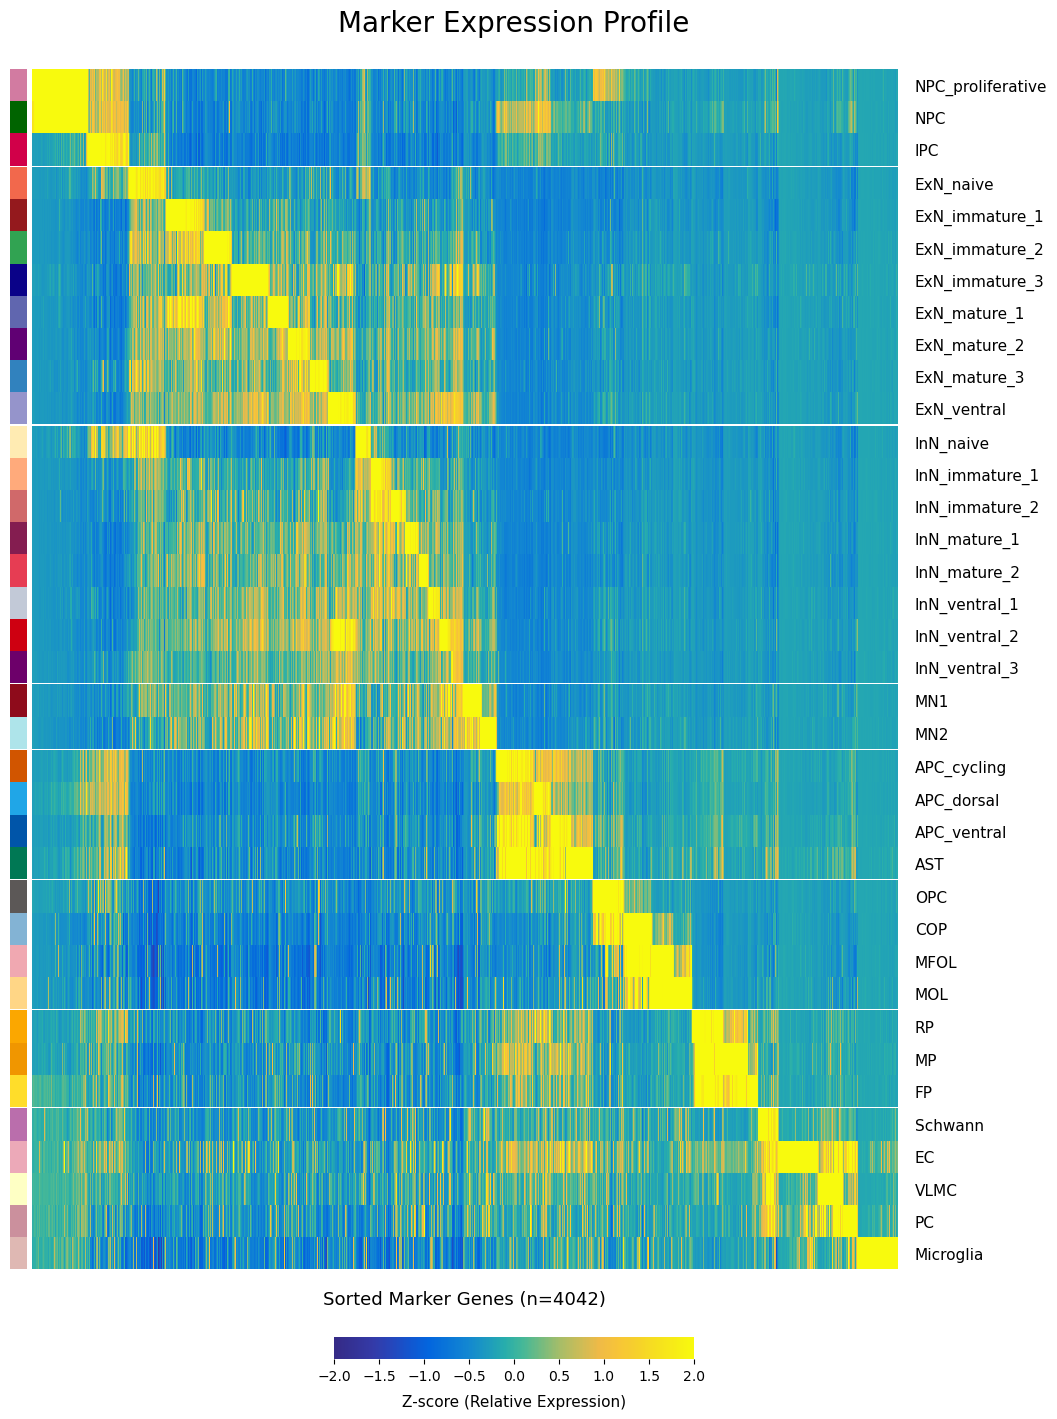

In [22]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.colors import ListedColormap
import matplotlib.patches as patches
import seaborn as sns

# 1. 定义大类分组
groups = {
    "Pro": ["NPC_proliferative", "NPC", "IPC"],
    "EX": ["ExN_naive", "ExN_immature_1", "ExN_immature_2", "ExN_immature_3", "ExN_mature_1", "ExN_mature_2", "ExN_mature_3", "ExN_ventral"],
    "IN": ["InN_naive", "InN_immature_1", "InN_immature_2", "InN_mature_1", "InN_mature_2", "InN_ventral_1", "InN_ventral_2", "InN_ventral_3"],
    "MN": ["MN1", "MN2"],
    "APC_AST": ["APC_cycling", "APC_dorsal", "APC_ventral", "AST"],
    "OPC_OL": ["OPC", "COP", "MFOL", "MOL"],
    "Ependymal": ["RP", "MP", "FP"],
    "Other": ["Schwann", "EC", "VLMC", "PC", "Microglia"]
}

active_groups = [(n, [t for t in ts if t in celltype_order]) for n, ts in groups.items() if any(t in celltype_order for t in ts)]

# 2. 建立布局
height_ratios = [len(types) for name, types in active_groups]
fig = plt.figure(figsize=(12, 15)) 

gs = gridspec.GridSpec(len(active_groups), 2, 
                       height_ratios=height_ratios, 
                       width_ratios=[0.2, 10], 
                       hspace=0.01, wspace=0.01)

# 3. 循环绘图
all_heat_axes = []
for i, (group_name, types) in enumerate(active_groups):
    # --- A. 左侧颜色块 (改为矢量 Patch 模式以适配 AI) ---
    ax_color = fig.add_subplot(gs[i, 0])
    group_colors = [my_colors[t] for t in types]
    
    # 设置坐标轴范围：y 轴从 n 到 0 (匹配热图从上到下的顺序)
    n_types = len(types)
    ax_color.set_ylim(n_types, 0) 
    ax_color.set_xlim(0, 1)
    
    for idx, color in enumerate(group_colors):
        # 为每个细胞类型画一个独立的矢量矩形
        rect = patches.Rectangle((0, idx), 1, 1, facecolor=color, edgecolor='none')
        ax_color.add_patch(rect)
    
    ax_color.set_xticks([])
    ax_color.set_yticks([])
    # 彻底关闭坐标轴线，确保 AI 中不产生多余的边框线
    ax_color.axis('off')
    
    # --- B. 主热图 (保持不变) ---
    ax_heat = fig.add_subplot(gs[i, 1])
    all_heat_axes.append(ax_heat)
    group_data = smoothed_df.loc[types]
    
    sns.heatmap(
        group_data,
        ax=ax_heat,
        cmap=RNA_cmap, 
        vmin=-2, vmax=2,
        xticklabels=False,
        yticklabels=True,
        cbar=False,
        rasterized=True # 热图主体保持栅格化，防止 AI 卡死
    )
    
    ax_heat.yaxis.tick_right()
    ax_heat.tick_params(axis='y', which='both', length=0, labelsize=11, rotation=0, pad=12)
    ax_heat.set_ylabel("")
    
    for spine in ax_heat.spines.values():
        spine.set_visible(False)

# 4. 底部设置 (保持不变)
all_heat_axes[-1].set_xlabel(f"Sorted Marker Genes (n={len(refined_genes)})", fontsize=13, labelpad=15)

# --- 5. 底部横向 Colorbar (确保也是矢量) ---
cbar_ax = fig.add_axes([0.35, 0.06, 0.3, 0.015]) 
sm = plt.cm.ScalarMappable(cmap=RNA_cmap, norm=plt.Normalize(vmin=-2, vmax=2))
cb = fig.colorbar(sm, cax=cbar_ax, orientation='horizontal')
cb.set_label('Z-score (Relative Expression)', fontsize=11, labelpad=8)
cb.outline.set_visible(False) 

# 6. 整体调整
plt.suptitle("Marker Expression Profile", fontsize=20, y=0.96)
plt.subplots_adjust(bottom=0.12, top=0.92, left=0.08, right=0.82)

# 注意：保存时一定要确保不设置 dpi 过低，矢量元素会保留
plt.savefig("Marker_Expression_Profile.pdf", dpi=300, bbox_inches='tight', transparent=True)
plt.show()

In [23]:
smoothed_df

,CDC25C,KIF14,KIF20A,CDCA2,KIF18B,CDCA8,BUB1,PIF1,TTK,ESPL1,...,SLFN11,MYO1F,TBXAS1,AC025569.1,MACORIS,LINC01141,ALOX5AP,ALOX5,ARHGDIB,C1QA
NPC_proliferative,5.651069,5.667311,5.684482,5.691110,5.692246,5.695642,5.696196,5.678596,5.635832,5.587622,...,-0.258981,-0.232588,-0.196134,-0.158646,-0.131398,-0.124779,-0.139731,-0.165924,-0.187060,-0.195344
NPC,1.772925,1.722038,1.665671,1.636160,1.612342,1.567162,1.528839,1.567771,1.710147,1.875526,...,-0.274110,-0.254258,-0.238393,-0.230806,-0.221669,-0.208620,-0.202743,-0.210341,-0.224365,-0.234099
IPC,-0.235117,-0.237651,-0.242158,-0.248194,-0.253639,-0.256385,-0.256783,-0.255825,-0.254181,-0.251779,...,-0.230945,-0.216552,-0.196357,-0.167222,-0.144124,-0.143237,-0.156484,-0.160330,-0.142219,-0.118536
ExN_naive,-0.255658,-0.249303,-0.243741,-0.245714,-0.253431,-0.261551,-0.268152,-0.271459,-0.269170,-0.263275,...,-0.257542,-0.241008,-0.226246,-0.215501,-0.204862,-0.192488,-0.189402,-0.205903,-0.231270,-0.246990
ExN_immature_1,-0.263114,-0.258181,-0.253895,-0.254574,-0.259863,-0.267974,-0.277076,-0.284053,-0.287077,-0.287935,...,-0.262544,-0.235944,-0.206255,-0.177996,-0.154859,-0.150670,-0.173880,-0.205854,-0.223356,-0.226300
ExN_immature_2,-0.268636,-0.266818,-0.264499,-0.263507,-0.265612,-0.271162,-0.277105,-0.280585,-0.283505,-0.288230,...,-0.248129,-0.217382,-0.188946,-0.161389,-0.132370,-0.118954,-0.135801,-0.168478,-0.193891,-0.205130
ExN_immature_3,-0.245158,-0.240408,-0.234857,-0.230095,-0.227013,-0.230767,-0.241125,-0.247428,-0.244305,-0.235948,...,-0.149982,-0.074007,-0.028842,-0.044526,-0.099646,-0.148120,-0.167327,-0.169136,-0.176217,-0.189152
ExN_mature_1,-0.266877,-0.267213,-0.267027,-0.264448,-0.259817,-0.257529,-0.260373,-0.265580,-0.270011,-0.273335,...,-0.179636,-0.145381,-0.116425,-0.099860,-0.093973,-0.102940,-0.133872,-0.176406,-0.208935,-0.222848
ExN_mature_2,-0.266447,-0.266554,-0.265322,-0.261140,-0.255799,-0.253617,-0.256048,-0.262220,-0.271140,-0.279604,...,-0.228383,-0.192469,-0.159721,-0.144871,-0.137030,-0.124209,-0.116314,-0.128403,-0.153901,-0.172133
ExN_mature_3,-0.258847,-0.256700,-0.252751,-0.248923,-0.246662,-0.247301,-0.252681,-0.261125,-0.267981,-0.271530,...,-0.224799,-0.218630,-0.196135,-0.180543,-0.177029,-0.176180,-0.178620,-0.195003,-0.223107,-0.244833


In [24]:
import pandas as pd

# 1. 重新构建基因与细胞类型的映射关系
# 逻辑必须与你绘图时的筛选逻辑完全一致
gene_to_ct = {}
processed_genes = set()

for ct in celltype_order:
    # 按照你之前的筛选逻辑提取基因
    sub_df = marker_cell_type[marker_cell_type['group'] == ct]
    sub_genes = sub_df.sort_values('logfoldchanges', ascending=False)['names'].head(200).tolist()
    
    for g in sub_genes:
        if g in adata.var_names and g not in processed_genes:
            gene_to_ct[g] = ct
            processed_genes.add(g)

# 2. 将 smoothed_df 转置 (变为 Gene x CellType)
# 确保只包含最终出现在热图里的 refined_genes
export_df = smoothed_df.T.copy()

# 3. 插入标注列
# 在第一列插入该基因所属的 Marker 组
export_df.insert(0, 'Marker_of_Group', [gene_to_ct.get(gene, "Unknown") for gene in export_df.index])

# 4. 导出 CSV
# 使用 utf_8_sig 编码确保 Excel 打开不乱码
export_df.to_csv("Expression_with_Annotations.csv", encoding='utf_8_sig')